# Tahap 2 � Full Fine-Tuning IndoBERT untuk Emotion Classification
Tujuan dari notebook ini adalah melakukan full fine-tuning model IndoBERT pada dataset PRDECT-ID. Seluruh parameter model akan di-update (trainable) untuk mendapatkan representasi emosi yang optimal. Hasil eksperimen mencakup metrik evaluasi, visualisasi, dan analisis kesalahan (error analysis).

## 1. Configuration & Setup
Mendefinisikan parameter eksperimen dan mengatur seed untuk reproducibility.

In [12]:
import os
import random
import json
import time
import math
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# --- Reproducibility ---
RANDOM_STATE = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# --- Hyperparameters ---
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
NUM_LABELS = 5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.0
EXPERIMENTS = {
    'A': 1e-5,
    'B': 2e-5,
    'C': 3e-5,
}
SELECTED_EXPERIMENT = 'A'
LEARNING_RATE = EXPERIMENTS[SELECTED_EXPERIMENT]

# --- Path Configuration ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
else:
    print("Running locally.")
    BASE_PATH = ".."

TRAIN_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_train.csv"
TEST_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_test.csv"
MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_map.json"
OUTPUT_DIR = f"{BASE_PATH}/outputs/finetuning_indobert"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/model", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/tokenizer", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {DEVICE}")
print(f"Selected experiment: {SELECTED_EXPERIMENT} -> LR={LEARNING_RATE}")

# --- Data loading helpers ---
class_map_path_candidates = [
    MAPPING_PATH,
    f"{BASE_PATH}/data/processed/prdect_label_mapping.json",
]

for candidate in class_map_path_candidates:
    if os.path.exists(candidate):
        MAPPING_PATH = candidate
        break

if not os.path.exists(MAPPING_PATH):
    raise FileNotFoundError(f"Label map not found. Tried: {class_map_path_candidates}")

TRAIN_SPLIT_RATIO = 0.10
LABEL_ORDER = ['happy', 'love', 'anger', 'fear', 'sadness']
EMOTION_MAP = {label: idx for idx, label in enumerate(LABEL_ORDER)}
ID2EMOTION = {idx: label for label, idx in EMOTION_MAP.items()}

def build_group_key(text: str) -> str:
    text = (text or '').lower().strip()
    return ' '.join(text.split())


Running in Google Colab. Mounting Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device used: cuda
Selected experiment: A -> LR=1e-05


## 2. Load Processed Dataset

In [13]:
df_train = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

with open(MAPPING_PATH, 'r') as f:
    label_mapping = json.load(f)

print(f"Train samples: {len(df_train)}")
print(f"Test samples : {len(df_test)}")
print("-" * 30)
print("Label Mapping:")
print(label_mapping)

# Normalize schema from preprocessing output
text_column = 'review_clean' if 'review_clean' in df_train.columns else 'Customer Review'
label_name_column = 'emotion_label' if 'emotion_label' in df_train.columns else 'Emotion'
label_id_column = 'label' if 'label' in df_train.columns else 'Label'
group_column = 'group_key' if 'group_key' in df_train.columns else None

train_df = df_train[[text_column, label_name_column, label_id_column] + ([group_column] if group_column else [])].copy()
test_df = df_test[[text_column, label_name_column, label_id_column] + ([group_column] if group_column else [])].copy()

train_df.columns = ['text', 'emotion_label', 'label'] + (['group_key'] if group_column else [])
test_df.columns = ['text', 'emotion_label', 'label'] + (['group_key'] if group_column else [])

train_df['emotion_label'] = train_df['emotion_label'].astype(str).str.lower().str.strip()
test_df['emotion_label'] = test_df['emotion_label'].astype(str).str.lower().str.strip()
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

if 'group_key' not in train_df.columns:
    train_df['group_key'] = train_df['text'].apply(build_group_key)
if 'group_key' not in test_df.columns:
    test_df['group_key'] = test_df['text'].apply(build_group_key)

# Group-aware split for robust validation (avoid identical texts across train/val)
group_df = train_df.groupby('group_key', as_index=False).agg(
    label=('label', 'first'),
    emotion_label=('emotion_label', 'first')
)
train_groups, val_groups = train_test_split(
    group_df,
    test_size=TRAIN_SPLIT_RATIO,
    random_state=RANDOM_STATE,
    stratify=group_df['label']
)

train_group_keys = set(train_groups['group_key'])
val_group_keys = set(val_groups['group_key'])

train_split_df = train_df[train_df['group_key'].isin(train_group_keys)].copy().reset_index(drop=True)
val_df = train_df[train_df['group_key'].isin(val_group_keys)].copy().reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_val_overlap = len(set(train_split_df['group_key']).intersection(set(val_df['group_key'])))
print(f"Train split : {len(train_split_df)}")
print(f"Validation  : {len(val_df)}")
print(f"Test        : {len(test_df)}")
print(f"Train/Val group overlap: {train_val_overlap}")

print("Train distribution:")
print(train_split_df['emotion_label'].value_counts())
print("Validation distribution:")
print(val_df['emotion_label'].value_counts())
print("Test distribution:")
print(test_df['emotion_label'].value_counts())


Train samples: 4319
Test samples : 1080
------------------------------
Label Mapping:
{'label2id': {'happy': 0, 'love': 1, 'anger': 2, 'fear': 3, 'sadness': 4}, 'id2label': {'0': 'happy', '1': 'love', '2': 'anger', '3': 'fear', '4': 'sadness'}}
Train split : 3888
Validation  : 431
Test        : 1080
Train/Val group overlap: 0
Train distribution:
emotion_label
happy      1274
sadness     865
fear        663
love        582
anger       504
Name: count, dtype: int64
Validation distribution:
emotion_label
happy      142
sadness     97
fear        73
love        64
anger       55
Name: count, dtype: int64
Test distribution:
emotion_label
happy      354
sadness    240
fear       184
love       162
anger      140
Name: count, dtype: int64


## 3. Tokenization
Menggunakan tokenizer IndoBERT untuk memproses teks menjadi format yang dimengerti model.

Original Text: bahannya tipis dan jahitannya kurang rapi
Tokens       : ['bahannya', 'tipis', 'dan', 'jahitan', '##nya', 'kurang', 'rapi']
Token IDs    : [17110, 5575, 41, 18722, 57, 1057, 6767]


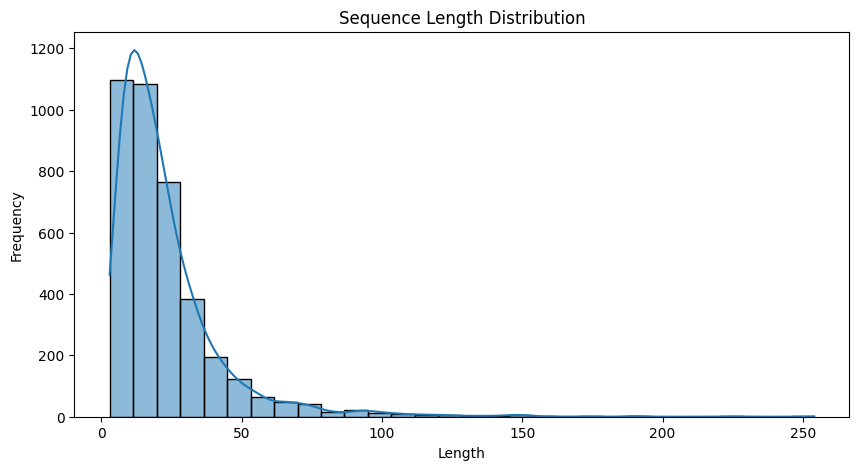

In [14]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test Tokenization
sample_text = train_split_df['text'].iloc[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {sample_text}")
print(f"Tokens       : {tokens}")
print(f"Token IDs    : {token_ids}")

# Visualize Sequence Length Distribution
lengths = train_split_df['text'].astype(str).apply(lambda x: len(tokenizer.encode(x)))
plt.figure(figsize=(10, 5))
sns.histplot(lengths, bins=30, kde=True)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


## 4. Dataset & DataLoader

In [15]:
class EmotionDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, item):
        review = str(self.reviews[item])
        label = int(self.labels[item])

        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(df, tokenizer, max_len, batch_size, shuffle=True):
    ds = EmotionDataset(
        reviews=df['text'].to_numpy(),
        labels=df['label'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

# Class weights from training split only
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.array(sorted(train_split_df['label'].unique())),
    y=train_split_df['label'].to_numpy(),
)
class_weights = torch.tensor(class_weight_values, dtype=torch.float32).to(DEVICE)
print('Class weights:', {ID2EMOTION[i]: float(w) for i, w in enumerate(class_weight_values)})

train_data_loader = create_data_loader(train_split_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=True)
val_data_loader = create_data_loader(val_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)
test_data_loader = create_data_loader(test_df, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)


Class weights: {'happy': 0.6103610675039246, 'love': 1.336082474226804, 'anger': 1.542857142857143, 'fear': 1.1728506787330317, 'sadness': 0.8989595375722543}


## 5. Full Fine-Tuning IndoBERT Initialization
Memuat pre-trained model dan memastikan seluruh parameter bersifat trainable.

In [16]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)
model = model.to(DEVICE)

# Verify all parameters are trainable (Full Fine-Tuning)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Example check
for name, param in model.named_parameters():
    if not param.requires_grad:
        print(f"WARNING: Parameter {name} is not trainable!")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters    : 124,445,189
Trainable Parameters: 124,445,189


## 6. Training Configuration & Loop

In [17]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_data_loader) * EPOCHS
warmup_steps = max(1, int(total_steps * WARMUP_RATIO))
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss(weight=class_weights).to(DEVICE)


def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    return {
        'accuracy': acc,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }


def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training")
    for d in progress_bar:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        loss = loss_fn(logits, labels)

        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        progress_bar.set_postfix({'loss': np.mean(losses)})

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics


def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            loss = loss_fn(logits, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_labels.extend(labels.detach().cpu().numpy().tolist())

    metrics = compute_metrics(all_labels, all_preds)
    return correct_predictions.double() / n_examples, np.mean(losses), metrics, all_labels, all_preds


## 7. Execution: Training Loop

In [18]:
history = {
    'epoch': [],
    'train_acc': [], 'train_loss': [],
    'val_acc': [], 'val_loss': [],
    'val_macro_f1': []
}
best_val_macro_f1 = -1
best_epoch = 0
patience_counter = 0
best_model_path = f'{OUTPUT_DIR}/model/best_model.bin'
training_history_path = f'{OUTPUT_DIR}/reports/training_history.csv'

start_time = time.time()

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    train_acc, train_loss, train_metrics = train_epoch(
        model, train_data_loader, loss_fn, optimizer, DEVICE, scheduler, len(train_split_df)
    )
    print(
        f"Train loss {train_loss:.4f} accuracy {train_acc:.4f} | "
        f"Macro F1 {train_metrics['macro_f1']:.4f}"
    )

    val_acc, val_loss, val_metrics, y_val, y_val_pred = eval_model(
        model, val_data_loader, loss_fn, DEVICE, len(val_df)
    )
    print(
        f"Val   loss {val_loss:.4f} accuracy {val_acc:.4f} | "
        f"Macro F1 {val_metrics['macro_f1']:.4f} | "
        f"Best {best_val_macro_f1:.4f} | Patience {patience_counter}/{PATIENCE}"
    )
    print()

    history['epoch'].append(epoch + 1)
    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)
    history['val_macro_f1'].append(val_metrics['macro_f1'])

    if val_metrics['macro_f1'] > best_val_macro_f1:
        torch.save(model.state_dict(), best_model_path)
        best_val_macro_f1 = val_metrics['macro_f1']
        best_epoch = epoch + 1
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f'Early stopping triggered at epoch {epoch + 1}. Best epoch: {best_epoch}.')
        break

end_time = time.time()
duration = end_time - start_time

history_df = pd.DataFrame(history)
history_df.to_csv(training_history_path, index=False)
print(f"Training completed in: {duration/60:.2f} minutes")
print(f"Best Val Macro F1 : {best_val_macro_f1:.4f} at epoch {best_epoch}")
print(f"Patience counter   : {patience_counter}/{PATIENCE}")


Epoch 1/10
----------


Training:   0%|          | 0/243 [00:00<?, ?it/s]

Train loss 1.2572 accuracy 0.4581 | Macro F1 0.4266
Val   loss 0.9339 accuracy 0.5081 | Macro F1 0.4793 | Best -1.0000 | Patience 0/3

Epoch 2/10
----------


Training:   0%|          | 0/243 [00:00<?, ?it/s]

Train loss 0.7732 accuracy 0.6674 | Macro F1 0.6430
Val   loss 0.7736 accuracy 0.7169 | Macro F1 0.6832 | Best 0.4793 | Patience 0/3

Epoch 3/10
----------


...

Train loss 0.1490 accuracy 0.9493 | Macro F1 0.9465
Val   loss 1.3547 accuracy 0.6937 | Macro F1 0.6476 | Best 0.6965 | Patience 0/3

Epoch 8/10
----------


Training:   0%|          | 0/243 [00:00<?, ?it/s]

Train loss 0.1113 accuracy 0.9658 | Macro F1 0.9634
Val   loss 1.5065 accuracy 0.6984 | Macro F1 0.6588 | Best 0.6965 | Patience 1/3

Epoch 9/10
----------


Training:   0%|          | 0/243 [00:00<?, ?it/s]

Train loss 0.0752 accuracy 0.9787 | Macro F1 0.9768
Val   loss 1.4546 accuracy 0.7077 | Macro F1 0.6730 | Best 0.6965 | Patience 2/3

Early stopping triggered at epoch 9. Best epoch: 6.
Training completed in: 13.42 minutes
Best Val Macro F1 : 0.6965 at epoch 6
Patience counter   : 3/3


## 8. Evaluation & Visualization

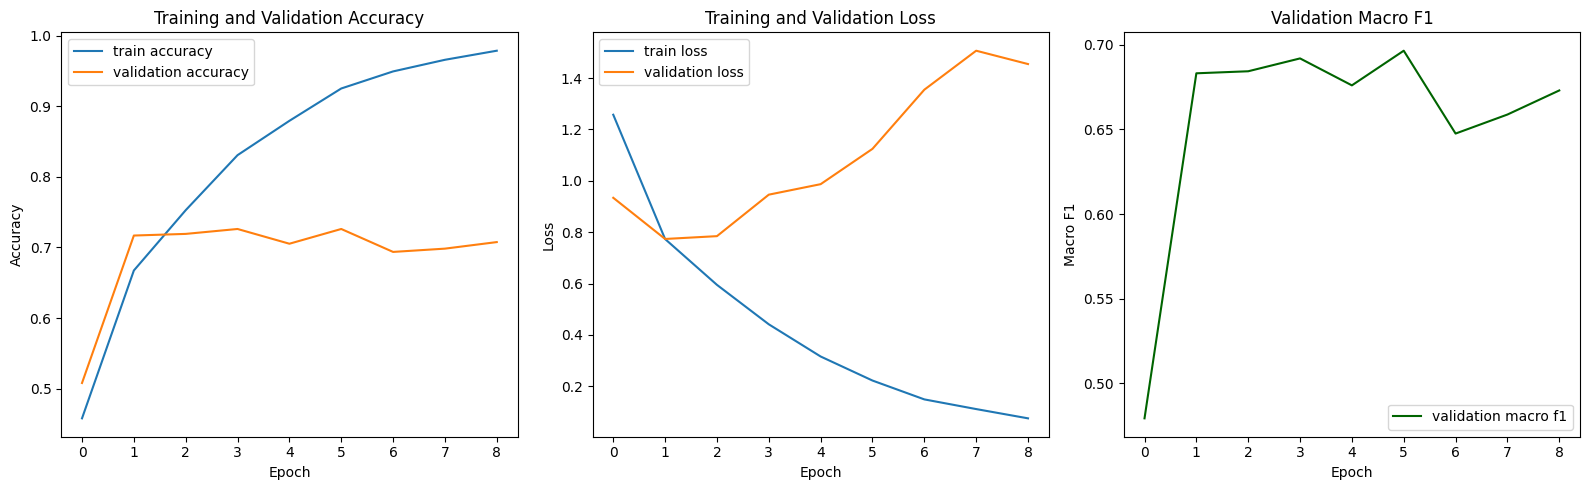

              precision    recall  f1-score   support

       happy     0.8457    0.8362    0.8409       354
        love     0.7160    0.7160    0.7160       162
       anger     0.6400    0.5714    0.6038       140
        fear     0.5105    0.5272    0.5187       184
     sadness     0.6601    0.6958    0.6775       240

    accuracy                         0.7000      1080
   macro avg     0.6745    0.6693    0.6714      1080
weighted avg     0.7012    0.7000    0.7002      1080



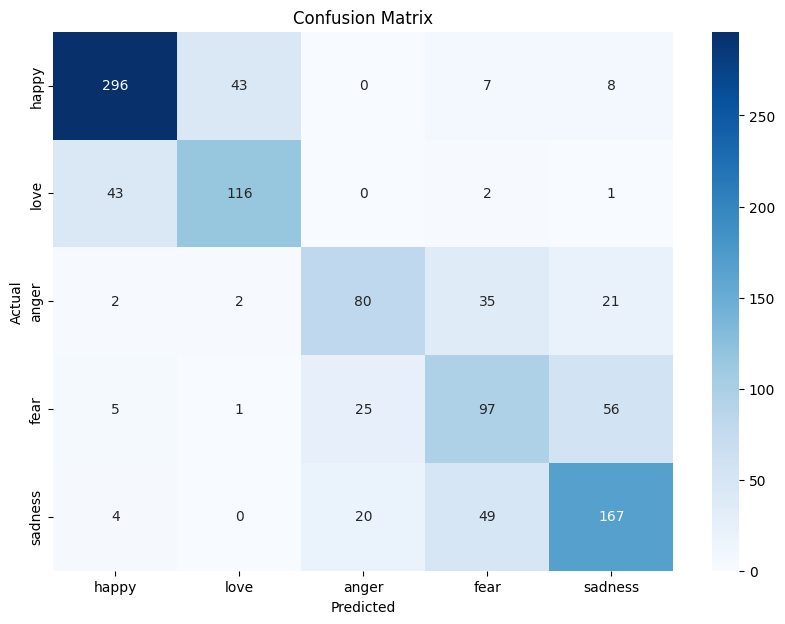

Test evaluation completed once using the best validation checkpoint.
Accuracy      : 0.7000
Macro Precision: 0.6745
Macro Recall   : 0.6693
Macro F1       : 0.6714
Weighted F1    : 0.7002


In [19]:
# Plotting Training Curves
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['val_macro_f1'], label='validation macro f1', color='darkgreen')
plt.title('Validation Macro F1')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png")
plt.show()

# Final Evaluation on Test Set uses best checkpoint only
best_model_state = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(best_model_state)

def get_predictions(model, data_loader):
    model = model.eval()
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(DEVICE)
            attention_mask = d["attention_mask"].to(DEVICE)
            labels = d["labels"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)

            review_texts.extend(texts)
            predictions.extend(preds.detach().cpu().tolist())
            prediction_probs.extend(probs.detach().cpu().tolist())
            real_values.extend(labels.detach().cpu().tolist())

    predictions = torch.tensor(predictions)
    prediction_probs = torch.tensor(prediction_probs)
    real_values = torch.tensor(real_values)
    return review_texts, predictions, prediction_probs, real_values

y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(model, test_data_loader)

# Classification Report
class_names = [ID2EMOTION[i] for i in range(NUM_LABELS)]
report = classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0)
print(report)
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.to_csv(f"{OUTPUT_DIR}/reports/classification_report.csv")
with open(f"{OUTPUT_DIR}/reports/classification_report.txt", "w") as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png")
plt.show()

final_acc = accuracy_score(y_test, y_pred)
final_macro_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
final_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
final_weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

final_metrics = {
    'test_accuracy': final_acc,
    'test_macro_precision': final_macro_precision,
    'test_macro_recall': final_macro_recall,
    'test_macro_f1': final_macro_f1,
    'test_weighted_f1': final_weighted_f1,
}
with open(f"{OUTPUT_DIR}/reports/test_metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print('Test evaluation completed once using the best validation checkpoint.')
print(f"Accuracy      : {final_acc:.4f}")
print(f"Macro Precision: {final_macro_precision:.4f}")
print(f"Macro Recall   : {final_macro_recall:.4f}")
print(f"Macro F1       : {final_macro_f1:.4f}")
print(f"Weighted F1    : {final_weighted_f1:.4f}")


## 9. Error Analysis
Menganalisis sampel yang diprediksi salah untuk memahami pola misklasifikasi model.

In [20]:
error_df = pd.DataFrame({
    'review_text': y_review_texts,
    'true_labels': y_test.tolist(),
    'pred_labels': y_pred.tolist(),
    'confidence': [probs[pred].item() for probs, pred in zip(y_pred_probs, y_pred)]
})

# Filter only errors
errors = error_df[error_df['true_labels'] != error_df['pred_labels']].copy()

# Map back to names
inv_mapping = {int(k): v for k, v in label_mapping.get('id2label', {}).items()} if isinstance(label_mapping, dict) and 'id2label' in label_mapping else {v: k for k, v in label_mapping.items()}
errors['true_emotion'] = errors['true_labels'].map(inv_mapping)
errors['pred_emotion'] = errors['pred_labels'].map(inv_mapping)

# Show Top 10 High-Confidence Errors
print("Top 10 High-Confidence Errors:")
display(errors.sort_values(by='confidence', ascending=False).head(10))

# Misclassification Pattern
error_pattern = errors.groupby(['true_emotion', 'pred_emotion']).size().reset_index(name='count')
error_pattern = error_pattern.sort_values(by='count', ascending=False)
print("\nTop Misclassification Patterns:")
display(error_pattern.head(10))

# Ensure the reports directory exists before saving
os.makedirs(f"{OUTPUT_DIR}/reports", exist_ok=True)

# Save Error Report
errors.to_csv(f"{OUTPUT_DIR}/reports/error_analysis.csv", index=False)

Top 10 High-Confidence Errors:


,review_text,true_labels,pred_labels,confidence,true_emotion,pred_emotion
422,"sesuai randomnya, bahan sesuai expektasi. teri...",1,0,0.991847,love,happy
488,"barang tiba dengan aman,mantap deh . terimakasih",1,0,0.991713,love,happy
654,bagus bgt seller baikbgt minta tolong kirim ha...,0,1,0.991378,happy,love
770,bagus banget bahan nya juga adem ini bakal jad...,0,1,0.990814,happy,love
24,jelek sekali packingnya.hand body saya pada tu...,3,2,0.990626,fear,anger
690,"kualitas kurang bagus, kalau di pegang masih m...",4,3,0.990493,sadness,fear
682,"barang bagus sesuai deskripsi, murah tapi gak ...",1,0,0.990254,love,happy
659,"sangat mengecewakan, hipseat dan baby carrier ...",3,4,0.989688,fear,sadness
1019,kendaraan menjadi kinclong kembali! mantap.,0,1,0.989236,happy,love
308,"pesen 2 lapis, dikasih selapis, untung aja vis...",2,0,0.989064,anger,happy



Top Misclassification Patterns:


,true_emotion,pred_emotion,count
7,fear,sadness,56
15,sadness,fear,49
9,happy,love,43
12,love,happy,43
0,anger,fear,35
4,fear,anger,25
3,anger,sadness,21
14,sadness,anger,20
10,happy,sadness,8
8,happy,fear,7


## 10. Save Model & Tokenizer

In [21]:
model.save_pretrained(f"{OUTPUT_DIR}/model/final_indobert_emotion")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer/indobert_tokenizer")

# Save Training History
with open(f"{OUTPUT_DIR}/reports/training_history.json", "w") as f:
    json.dump(history, f)

print(f"All assets saved to: {OUTPUT_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All assets saved to: /content/drive/MyDrive/xai_lime_vs_shap/outputs/finetuning_indobert


## 11. Experiment Summary

In [22]:
total_dataset = len(train_df) + len(test_df)
final_accuracy = accuracy_score(y_test, y_pred)
final_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print("=== FINAL EXPERIMENT SUMMARY ===")
print(f"Model Name           : {MODEL_NAME}")
print(f"Total Dataset        : {total_dataset}")
print(f"Train / Val / Test    : {len(train_split_df)} / {len(val_df)} / {len(test_df)}")
print(f"Epochs               : {EPOCHS}")
print(f"Learning Rate        : {LEARNING_RATE}")
print(f"Best Val Macro F1    : {best_val_macro_f1:.4f}")
print(f"Final Test Accuracy  : {final_accuracy:.4f}")
print(f"Final Test F1 (Macro): {final_f1_macro:.4f}")
print(f"Training Duration    : {duration/60:.2f} minutes")
print(f"Random State         : {RANDOM_STATE}")
print(f"Timestamp            : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


=== FINAL EXPERIMENT SUMMARY ===
Model Name           : indobenchmark/indobert-base-p1
Total Dataset        : 5399
Train / Val / Test    : 3888 / 431 / 1080
Epochs               : 10
Learning Rate        : 1e-05
Best Val Macro F1    : 0.6965
Final Test Accuracy  : 0.7000
Final Test F1 (Macro): 0.6714
Training Duration    : 13.42 minutes
Random State         : 42
Timestamp            : 2026-06-02 15:10:09
